In [2]:
import pandas as pd
data = pd.read_csv("Demanda.csv")
data

,Fecha,Hora,Parada,Numero de pasajeros,Eventos especiales,Dia de la semana,Flujo de personas,Flujo de choferes,Eventos inesperados,Clima,Unnamed: 10
0,4/22/2024,6:00,Obrajes,2,0,Lunes,6,2,0,sol,NaN
1,4/22/2024,6:15,Obrajes,0,0,Lunes,4,2,0,sol,NaN
2,4/22/2024,6:30,Obrajes,0,0,Lunes,4,4,0,sol,NaN
3,4/22/2024,6:45,Obrajes,2,0,Lunes,5,6,0,sol,NaN
4,4/22/2024,7:00,Obrajes,3,0,Lunes,4,9,0,sol,NaN
...,...,...,...,...,...,...,...,...,...,...,...
4083,6/16/2024,23:00,Obrajes,0,0,Domingo,0,0,0,sol,NaN
4084,6/16/2024,23:15,Obrajes,0,0,Domingo,0,0,0,sol,NaN
4085,6/16/2024,23:30,Obrajes,0,0,Domingo,0,0,0,sol,NaN
4086,6/16/2024,23:45,Obrajes,0,0,Domingo,0,0,0,sol,NaN


In [3]:
data = pd.read_csv("Demanda.csv")
data = data.drop("Unnamed: 10", axis=1)
data

,Fecha,Hora,Parada,Numero de pasajeros,Eventos especiales,Dia de la semana,Flujo de personas,Flujo de choferes,Eventos inesperados,Clima
0,4/22/2024,6:00,Obrajes,2,0,Lunes,6,2,0,sol
1,4/22/2024,6:15,Obrajes,0,0,Lunes,4,2,0,sol
2,4/22/2024,6:30,Obrajes,0,0,Lunes,4,4,0,sol
3,4/22/2024,6:45,Obrajes,2,0,Lunes,5,6,0,sol
4,4/22/2024,7:00,Obrajes,3,0,Lunes,4,9,0,sol
...,...,...,...,...,...,...,...,...,...,...
4083,6/16/2024,23:00,Obrajes,0,0,Domingo,0,0,0,sol
4084,6/16/2024,23:15,Obrajes,0,0,Domingo,0,0,0,sol
4085,6/16/2024,23:30,Obrajes,0,0,Domingo,0,0,0,sol
4086,6/16/2024,23:45,Obrajes,0,0,Domingo,0,0,0,sol


Resumen Estadístico:
                                Fecha                       Hora   Parada  \
count                            4088                       4088     4088   
unique                            NaN                        NaN        1   
top                               NaN                        NaN  Obrajes   
freq                              NaN                        NaN     4088   
mean    2024-05-19 11:59:17.729941504  0 days 14:40:16.438356164      NaN   
min               2024-04-22 00:00:00            0 days 00:00:00      NaN   
25%               2024-05-05 18:00:00            0 days 10:15:00      NaN   
50%               2024-05-19 12:00:00            0 days 14:45:00      NaN   
75%               2024-06-02 06:00:00            0 days 19:15:00      NaN   
max               2024-06-16 00:00:00            0 days 23:45:00      NaN   
std                               NaN  0 days 05:26:33.315744410      NaN   

        Numero de pasajeros  Eventos especiales Dia de

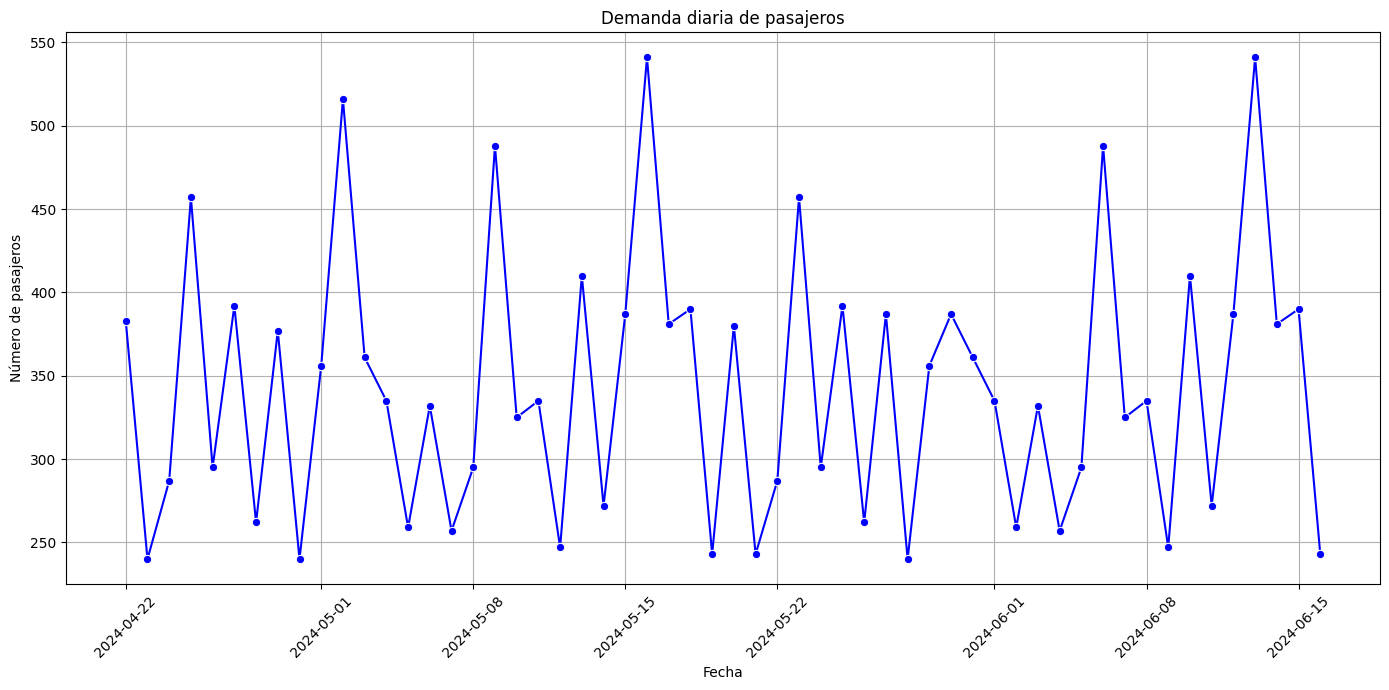

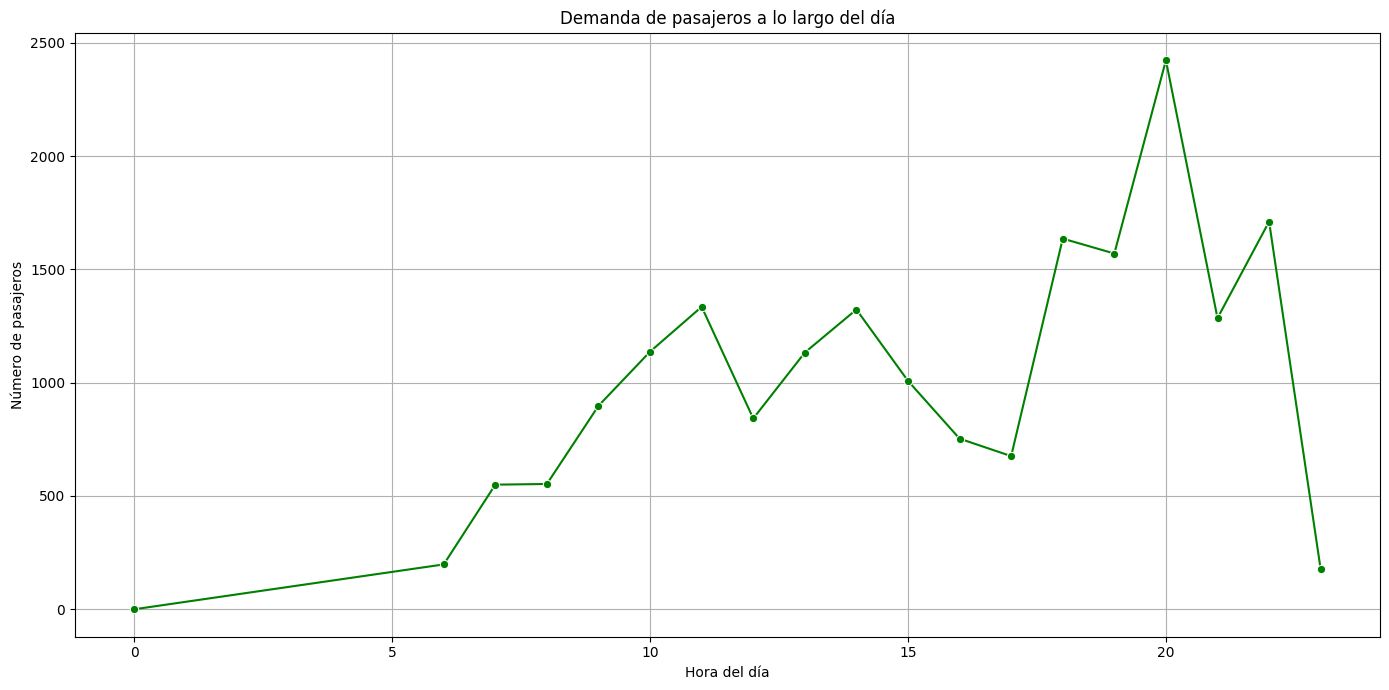

C:\Users\OMEN\AppData\Local\Temp\ipykernel_8812\3476622122.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=parada_demand['Parada'], y=parada_demand['Numero de pasajeros'], palette='viridis')


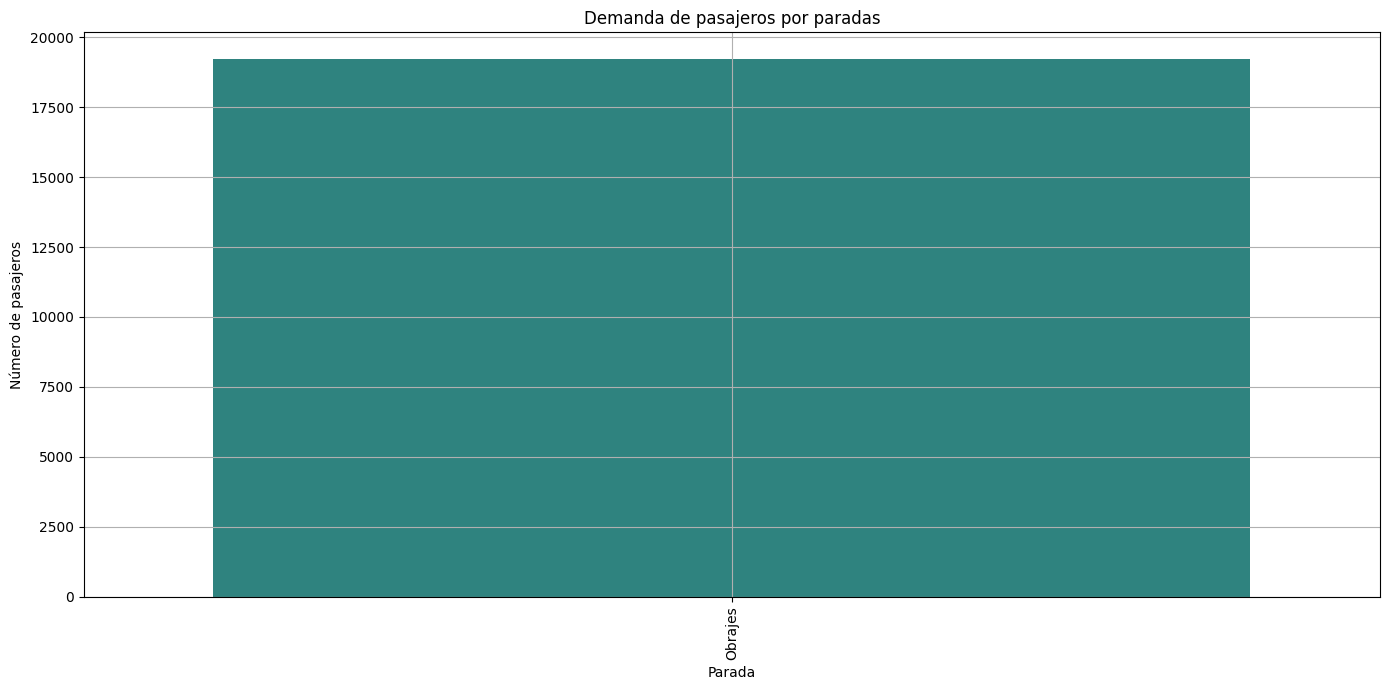

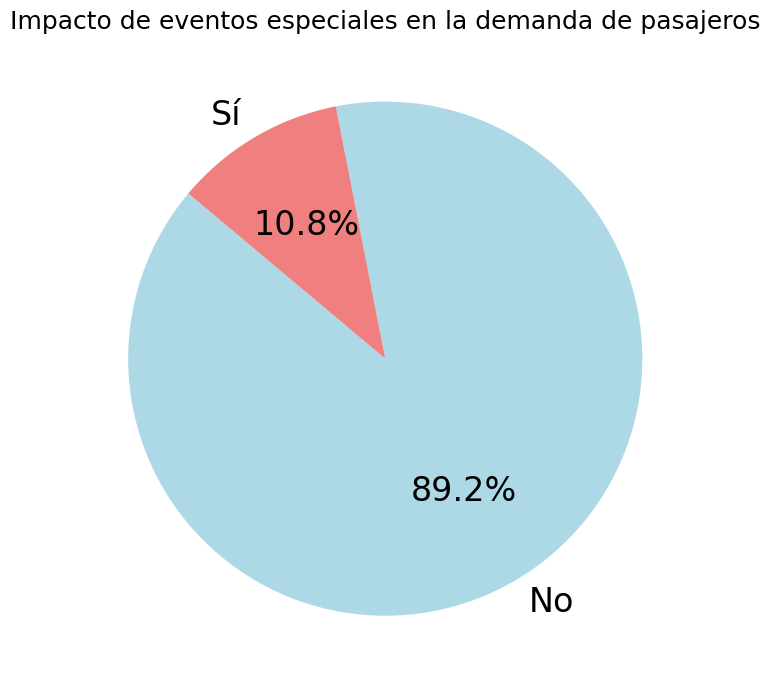

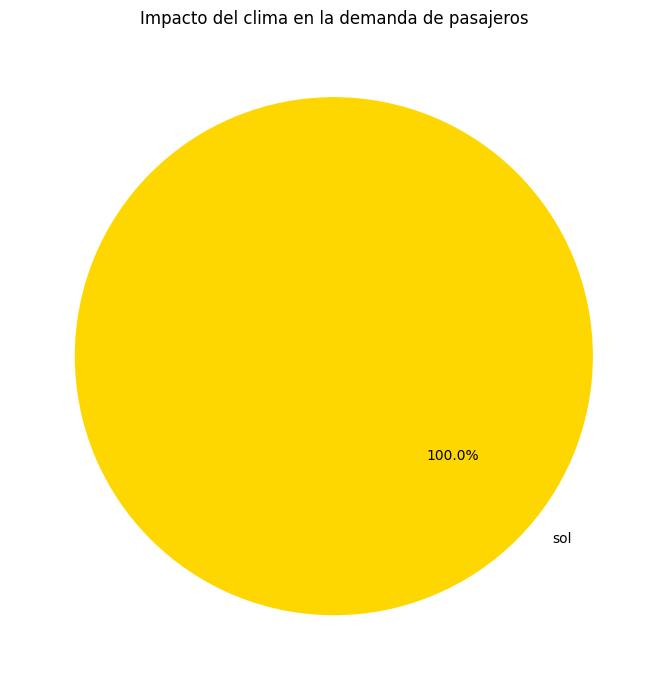

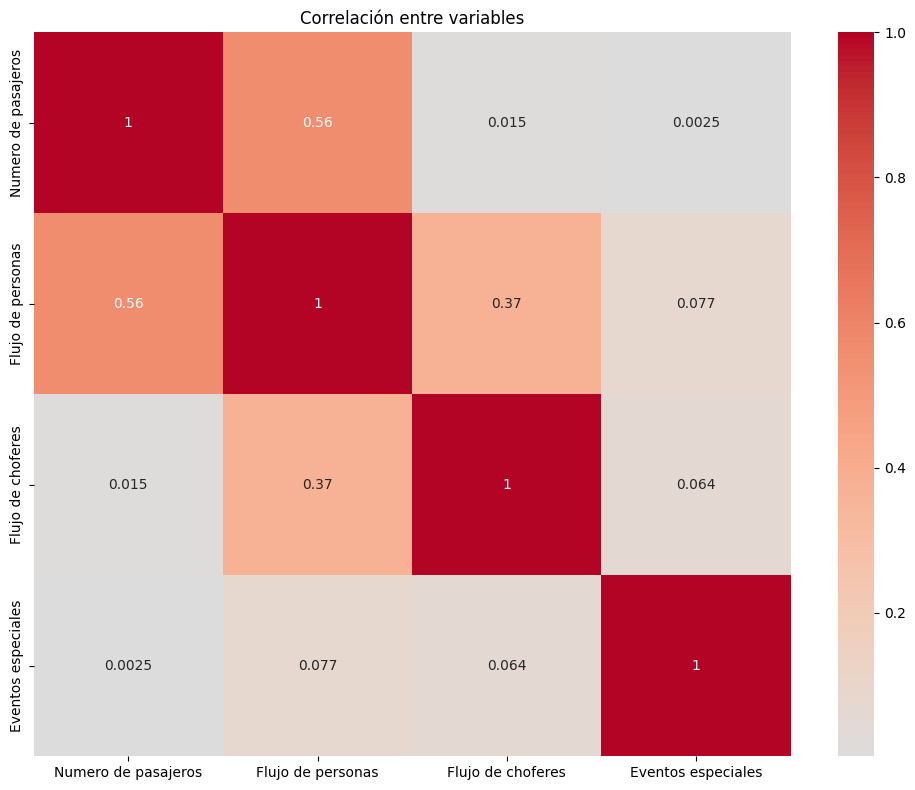

C:\Users\OMEN\AppData\Local\Temp\ipykernel_8812\3476622122.py:129: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weekly_demand_no_feriados['Dia de la semana'], y=weekly_demand_no_feriados['Numero de pasajeros'], palette='viridis')


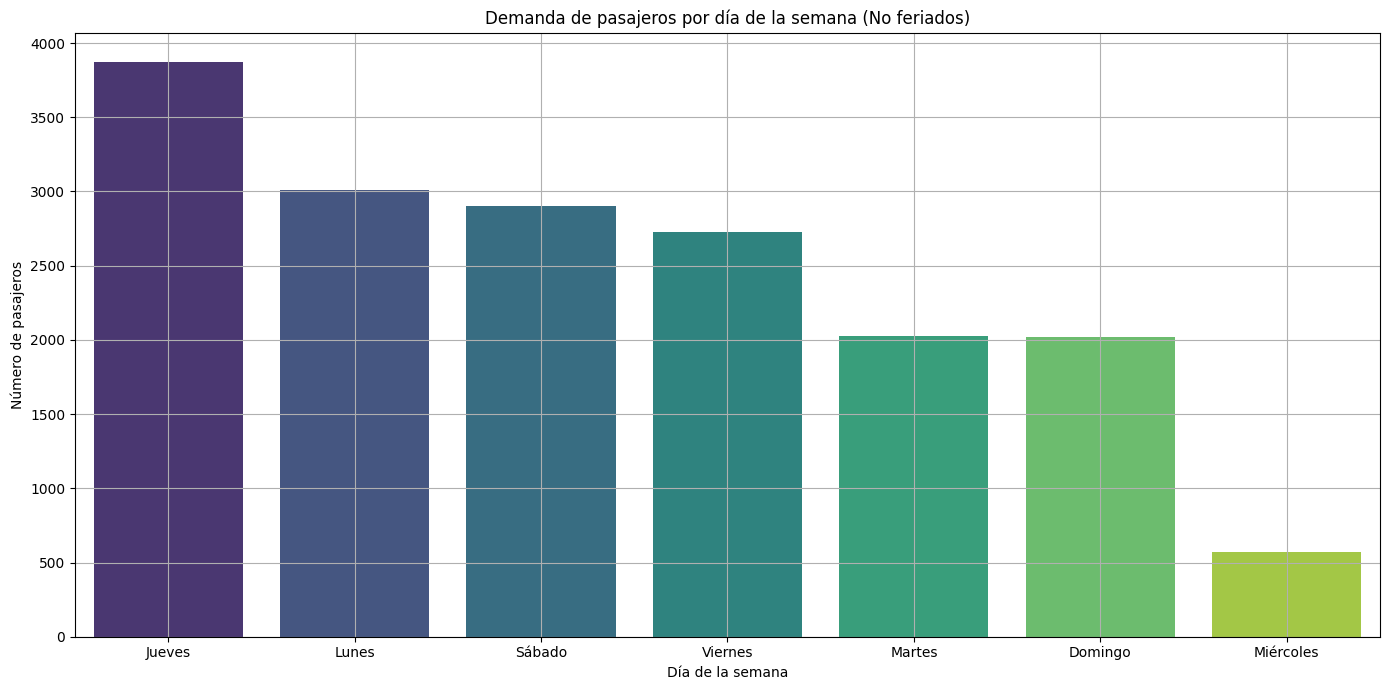

C:\Users\OMEN\AppData\Local\Temp\ipykernel_8812\3476622122.py:142: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weekly_demand_feriados['Dia de la semana'], y=weekly_demand_feriados['Numero de pasajeros'], palette='viridis')


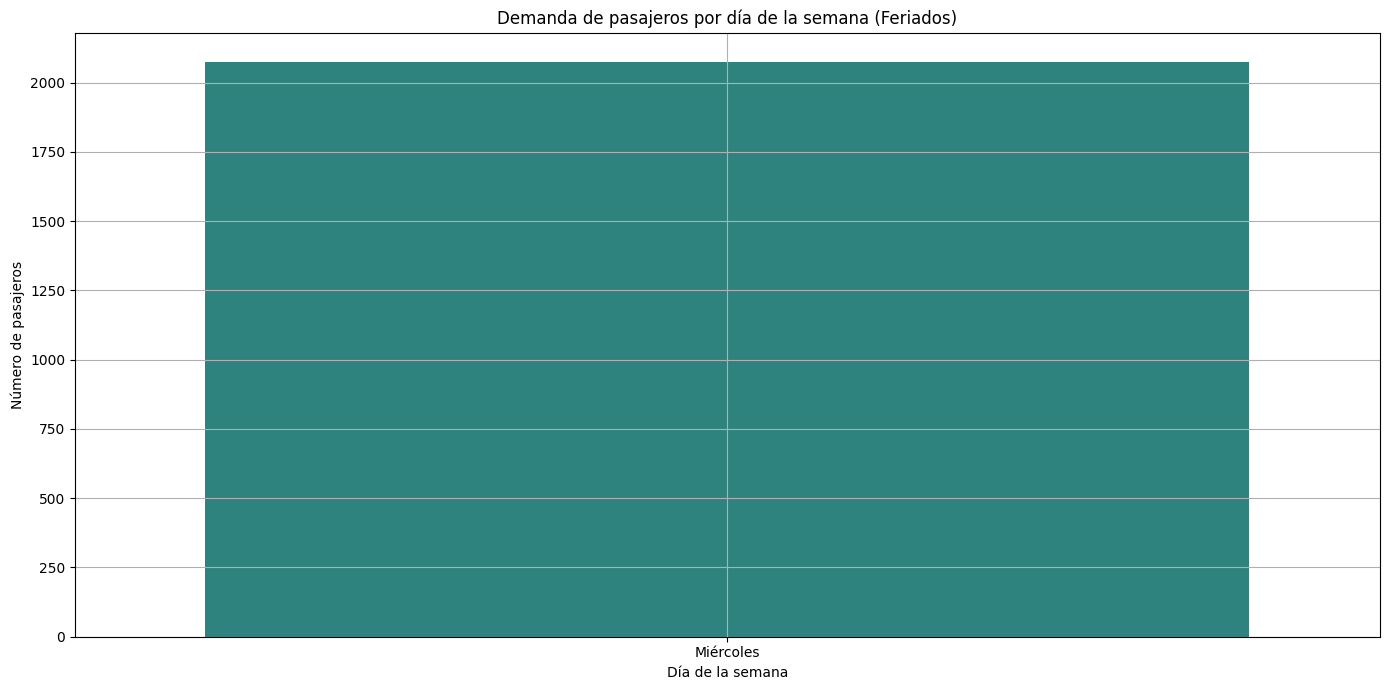

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Leer el archivo CSV
data = pd.read_csv("Demanda.csv")

# Eliminar columna innecesaria
if 'Unnamed: 10' in data.columns:
    data = data.drop("Unnamed: 10", axis=1)

# Limpiar nombres de columnas
data.columns = data.columns.str.strip()

# Convertir la columna 'Fecha' a formato de fecha
data['Fecha'] = pd.to_datetime(data['Fecha'])

# Función para limpiar y dar formato a la columna 'Hora'
def clean_hour(hour_str):
    try:
        if pd.isna(hour_str):
            return pd.NaT
        else:
            return f"{int(hour_str.split(':')[0]):02}:{int(hour_str.split(':')[1]):02}"
    except (AttributeError, ValueError):
        return pd.NaT  # Devuelve NaT si hay valores no válidos

# Aplicar la limpieza de la columna 'Hora'
data['Hora'] = data['Hora'].astype(str).apply(clean_hour)
data = data.dropna(subset=['Hora'])
data['Hora'] = pd.to_timedelta(data['Hora'] + ':00')

# Limpiar los valores de 'Día de la semana'
data['Dia de la semana'] = data['Dia de la semana'].str.strip().replace("Miercoles", "Miércoles")

# Revisar si 'Eventos especiales' indica días feriados
# Se considera feriado si 'Eventos especiales' es igual a 1
data['Feriado'] = data['Eventos especiales']

# Resumen estadístico
print("Resumen Estadístico:")
print(data.describe(include='all'))

# Distribución de Eventos Especiales
print("\nDistribución de Eventos Especiales:")
print(data['Eventos especiales'].value_counts())

# Distribución de Días de la Semana
print("\nDistribución de Días de la Semana:")
print(data['Dia de la semana'].value_counts())

# Distribución del Clima
print("\nDistribución del Clima:")
print(data['Clima'].value_counts())

# Gráfico de la demanda diaria de pasajeros
daily_demand = data.groupby('Fecha')['Numero de pasajeros'].sum().reset_index()
plt.figure(figsize=(14, 7))
sns.lineplot(x=daily_demand['Fecha'], y=daily_demand['Numero de pasajeros'], marker='o', color='blue')
plt.title('Demanda diaria de pasajeros')
plt.xlabel('Fecha')
plt.ylabel('Número de pasajeros')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# Gráfico de la demanda por horas del día
hourly_demand = data.groupby(data['Hora'].dt.components['hours'])['Numero de pasajeros'].sum().reset_index()
plt.figure(figsize=(14, 7))
sns.lineplot(x=hourly_demand['hours'], y=hourly_demand['Numero de pasajeros'], marker='o', color='green')
plt.title('Demanda de pasajeros a lo largo del día')
plt.xlabel('Hora del día')
plt.ylabel('Número de pasajeros')
plt.grid(True)
plt.tight_layout()
plt.show()

# Gráfico de la demanda por paradas
parada_demand = data.groupby('Parada')['Numero de pasajeros'].sum().reset_index()
plt.figure(figsize=(14, 7))
sns.barplot(x=parada_demand['Parada'], y=parada_demand['Numero de pasajeros'], palette='viridis')
plt.title('Demanda de pasajeros por paradas')
plt.xlabel('Parada')
plt.ylabel('Número de pasajeros')
plt.grid(True)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Gráfico de impacto de eventos especiales
eventos_demand = data.groupby('Eventos especiales')['Numero de pasajeros'].sum().reset_index()

plt.figure(figsize=(14, 7))
plt.pie(
    eventos_demand['Numero de pasajeros'], 
    labels=eventos_demand['Eventos especiales'].map({0: 'No', 1: 'Sí'}), 
    autopct='%1.1f%%', 
    colors=['lightblue', 'lightcoral'], 
    startangle=140, 
    textprops={'fontsize': 24}  # Aumentar tamaño de letra aún más
)
plt.title('Impacto de eventos especiales en la demanda de pasajeros', fontsize=18)  # Aumentar tamaño del título
plt.tight_layout()
plt.show()


# Gráfico de impacto del clima en la demanda
clima_demand = data.groupby('Clima')['Numero de pasajeros'].sum().reset_index()
plt.figure(figsize=(14, 7))
plt.pie(clima_demand['Numero de pasajeros'], labels=clima_demand['Clima'], autopct='%1.1f%%', colors=['gold', 'skyblue'], startangle=140)
plt.title('Impacto del clima en la demanda de pasajeros')
plt.tight_layout()
plt.show()

# Matriz de correlación entre variables
corr_matrix = data[['Numero de pasajeros', 'Flujo de personas', 'Flujo de choferes', 'Eventos especiales']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlación entre variables')
plt.tight_layout()
plt.show()

# Análisis de demanda en días no feriados
data_no_feriados = data[data['Feriado'] == 0]
weekly_demand_no_feriados = data_no_feriados.groupby('Dia de la semana')['Numero de pasajeros'].sum().reset_index()
weekly_demand_no_feriados = weekly_demand_no_feriados.sort_values(by='Numero de pasajeros', ascending=False)
plt.figure(figsize=(14, 7))
sns.barplot(x=weekly_demand_no_feriados['Dia de la semana'], y=weekly_demand_no_feriados['Numero de pasajeros'], palette='viridis')
plt.title('Demanda de pasajeros por día de la semana (No feriados)')
plt.xlabel('Día de la semana')
plt.ylabel('Número de pasajeros')
plt.grid(True)
plt.tight_layout()
plt.show()

# Análisis de demanda en días feriados
data_feriados = data[data['Feriado'] == 1]
weekly_demand_feriados = data_feriados.groupby('Dia de la semana')['Numero de pasajeros'].sum().reset_index()
weekly_demand_feriados = weekly_demand_feriados.sort_values(by='Numero de pasajeros', ascending=False)
plt.figure(figsize=(14, 7))
sns.barplot(x=weekly_demand_feriados['Dia de la semana'], y=weekly_demand_feriados['Numero de pasajeros'], palette='viridis')
plt.title('Demanda de pasajeros por día de la semana (Feriados)')
plt.xlabel('Día de la semana')
plt.ylabel('Número de pasajeros')
plt.grid(True)
plt.tight_layout()
plt.show()


Demanda promedio de pasajeros en un día normal: 342.75
Demanda total de pasajeros en días feriados: 356.00


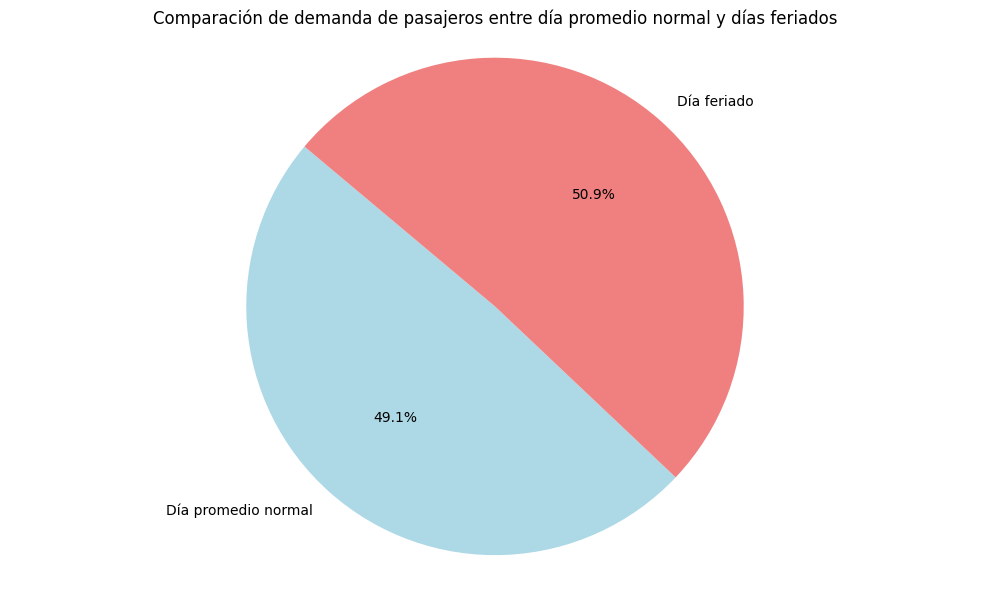

In [5]:
# Ahora que el archivo correcto ha sido cargado, procederé a utilizarlo para el análisis

# Leer el archivo CSV
data = pd.read_csv("Demanda.csv")

# Eliminar columna innecesaria si existe
if 'Unnamed: 10' in data.columns:
    data = data.drop("Unnamed: 10", axis=1)

# Limpiar nombres de columnas
data.columns = data.columns.str.strip()

# Convertir la columna 'Fecha' a formato de fecha
data['Fecha'] = pd.to_datetime(data['Fecha'])

# Función para limpiar y dar formato a la columna 'Hora'
def clean_hour(hour_str):
    try:
        return f"{int(hour_str.split(':')[0]):02}:{int(hour_str.split(':')[1]):02}"
    except AttributeError:
        return pd.NaT
    except ValueError:
        return pd.NaT

# Aplicar la limpieza de la columna 'Hora'
data['Hora'] = data['Hora'].astype(str).apply(clean_hour)
data = data.dropna(subset=['Hora'])  # Eliminar filas con valores de hora no válidos

# Convertir la columna 'Hora' en formato de timedelta
data['Hora'] = pd.to_timedelta(data['Hora'] + ':00')

# Limpiar los valores de 'Día de la semana'
data['Dia de la semana'] = data['Dia de la semana'].str.strip().replace("Miercoles", "Miércoles")

# Lista de feriados actualizada
feriados = ['2024-05-01', '2024-06-21', '2024-07-16']  # Añadir más días feriados si es necesario
data['Feriado'] = data['Fecha'].dt.strftime('%Y-%m-%d').isin(feriados).astype(int)

# Filtrar datos en días feriados y no feriados
data_no_feriados = data[data['Feriado'] == 0]
data_feriados = data[data['Feriado'] == 1]

# Calcular demanda total de pasajeros en días feriados
total_pasajeros_feriados = data_feriados['Numero de pasajeros'].sum()

# Calcular promedio de pasajeros en días normales
promedio_pasajeros_normal = data_no_feriados.groupby('Fecha')['Numero de pasajeros'].sum().mean()

# Imprimir resultados
print(f"Demanda promedio de pasajeros en un día normal: {promedio_pasajeros_normal:.2f}")
print(f"Demanda total de pasajeros en días feriados: {total_pasajeros_feriados:.2f}")

# Graficar la comparación entre días normales y días feriados
plt.figure(figsize=(10, 6))
sizes = [promedio_pasajeros_normal, total_pasajeros_feriados]
labels = ['Día promedio normal', 'Día feriado']
colors = ['lightblue', 'lightcoral']
plt.pie(
    sizes, 
    labels=labels, 
    autopct='%1.1f%%', 
    colors=colors, 
    startangle=140, 
    textprops={'fontsize': 18}  # Aumentar tamaño de letra para los porcentajes
)
plt.title('Comparación de demanda de pasajeros entre día promedio normal y días feriados', fontsize=20)  # Aumentar tamaño del título
plt.axis('equal')  
plt.tight_layout()
plt.show()




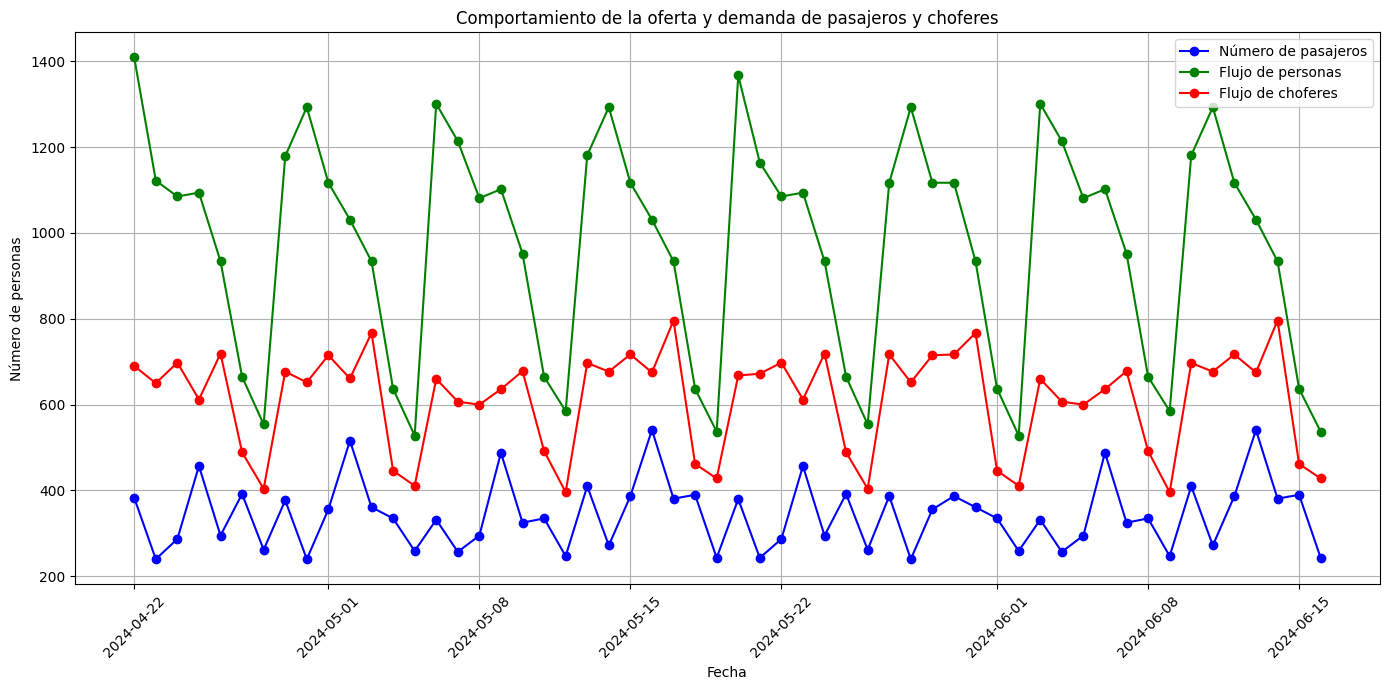

In [6]:
# Actualizando el código con el nuevo dataset proporcionado anteriormente.

# Leer el archivo CSV
data = pd.read_csv("Demanda.csv")

# Eliminar columna innecesaria si existe
if 'Unnamed: 10' in data.columns:
    data = data.drop("Unnamed: 10", axis=1)

# Limpiar nombres de columnas
data.columns = data.columns.str.strip()

# Convertir la columna 'Fecha' a formato de fecha
data['Fecha'] = pd.to_datetime(data['Fecha'])

# Función para limpiar y dar formato a la columna 'Hora'
def clean_hour(hour_str):
    try:
        return f"{int(hour_str.split(':')[0]):02}:{int(hour_str.split(':')[1]):02}"
    except AttributeError:
        return pd.NaT
    except ValueError:
        return pd.NaT

# Aplicar la limpieza de la columna 'Hora'
data['Hora'] = data['Hora'].astype(str).apply(clean_hour)
data = data.dropna(subset=['Hora'])  # Eliminar filas con valores de hora no válidos

# Convertir la columna 'Hora' en formato de timedelta
data['Hora'] = pd.to_timedelta(data['Hora'] + ':00')

# Limpiar los valores de 'Día de la semana'
data['Dia de la semana'] = data['Dia de la semana'].str.strip().replace("Miercoles", "Miércoles")

# Lista de feriados actualizada
feriados = ['2024-05-01', '2024-06-21', '2024-07-16']  # Añadir más días feriados si es necesario
data['Feriado'] = data['Fecha'].dt.strftime('%Y-%m-%d').isin(feriados).astype(int)

# Agrupando los datos diarios por fecha y sumando el número de pasajeros, flujo de personas y flujo de choferes
daily_data = data.groupby('Fecha')[['Numero de pasajeros', 'Flujo de personas', 'Flujo de choferes']].sum().reset_index()

# Graficando el comportamiento de la oferta y demanda de pasajeros y choferes
plt.figure(figsize=(14, 7))
plt.plot(daily_data['Fecha'], daily_data['Numero de pasajeros'], marker='o', label='Número de pasajeros', color='blue')
plt.plot(daily_data['Fecha'], daily_data['Flujo de personas'], marker='o', label='Flujo de personas', color='green')
plt.plot(daily_data['Fecha'], daily_data['Flujo de choferes'], marker='o', label='Flujo de choferes', color='red')
plt.title('Comportamiento de la oferta y demanda de pasajeros y choferes')
plt.xlabel('Fecha')
plt.ylabel('Número de personas')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Leer el archivo CSV
data = pd.read_csv("Demanda.csv")

# Eliminar columnas innecesarias
if 'Unnamed: 10' in data.columns:
    data = data.drop("Unnamed: 10", axis=1)

# Limpiar nombres de columnas
data.columns = data.columns.str.strip()

# Convertir la columna 'Fecha' a formato de fecha
data['Fecha'] = pd.to_datetime(data['Fecha'])

# Función para limpiar y dar formato a la columna 'Hora'
def clean_hour(hour_str):
    try:
        return f"{int(hour_str.split(':')[0]):02}:{int(hour_str.split(':')[1]):02}"
    except AttributeError:
        return pd.NaT
    except ValueError:
        return pd.NaT

# Aplicar la limpieza de la columna 'Hora'
data['Hora'] = data['Hora'].astype(str).apply(clean_hour)
data = data.dropna(subset=['Hora'])  # Eliminar filas con valores de hora no válidos

# Convertir la columna 'Hora' en formato de timedelta
data['Hora'] = pd.to_timedelta(data['Hora'] + ':00')

# Ajustar el nombre de la columna 'Día de la semana'
data['Dia de la semana'] = data['Dia de la semana'].str.strip().replace("Miercoles", "Miércoles")

# Crear la variable objetivo 'Feriado' basada en eventos especiales
data['Feriado'] = data['Eventos especiales']

# Seleccionar las variables predictoras (X) y la variable objetivo (y)
X = data[['Flujo de personas', 'Flujo de choferes', 'Feriado', 'Eventos inesperados']]
y = data['Numero de pasajeros']

# Dividir el dataset en conjuntos de entrenamiento y prueba (80% - 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar las características (Normalización)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [8]:
# Mostrar las primeras filas de los datos escalados
print("Datos de entrenamiento (escalados):")
print(pd.DataFrame(X_train_scaled, columns=X.columns).head())

print("\nVariable objetivo (Número de pasajeros):")
y_train.head()



Datos de entrenamiento (escalados):
   Flujo de personas  Flujo de choferes   Feriado  Eventos inesperados
0          -0.889647          -1.335242 -0.343993                  0.0
1          -0.018012          -0.078950 -0.343993                  0.0
2          -0.142531           0.130431 -0.343993                  0.0
3           0.231027           0.967959 -0.343993                  0.0
4           1.725260           0.549195 -0.343993                  0.0

Variable objetivo (Número de pasajeros):


2044    2
2464    6
2821    3
2059    0
1813    0
Name: Numero de pasajeros, dtype: int64

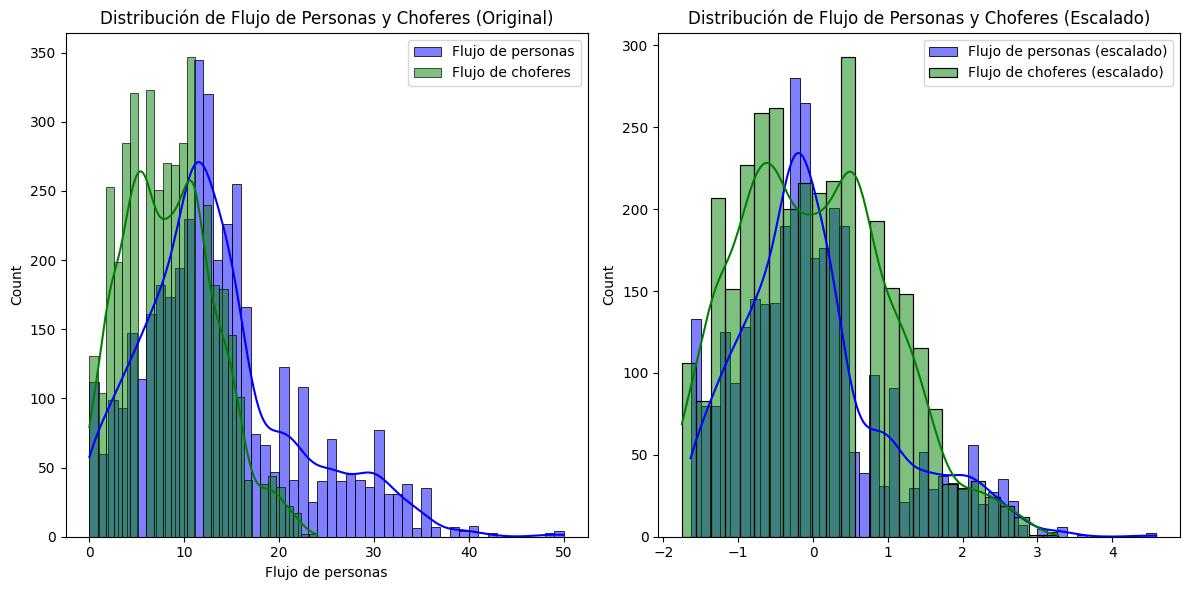

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Graficar las distribuciones de las variables antes del escalado
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(X['Flujo de personas'], kde=True, color='blue', label='Flujo de personas')
sns.histplot(X['Flujo de choferes'], kde=True, color='green', label='Flujo de choferes')
plt.title('Distribución de Flujo de Personas y Choferes (Original)')
plt.legend()

# Graficar las distribuciones después del escalado
plt.subplot(1, 2, 2)
sns.histplot(X_train_scaled[:, 0], kde=True, color='blue', label='Flujo de personas (escalado)')
sns.histplot(X_train_scaled[:, 1], kde=True, color='green', label='Flujo de choferes (escalado)')
plt.title('Distribución de Flujo de Personas y Choferes (Escalado)')
plt.legend()

plt.tight_layout()
plt.show()


In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Definir los modelos
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42) 
}

# Entrenar y evaluar los modelos
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results[name] = {"MAE": mae, "RMSE": rmse}

# Mostrar los resultados de la evaluación
print("Resultados de los modelos:")
for model_name, metrics in results.items():
    print(f"{model_name}: MAE = {metrics['MAE']}, RMSE = {metrics['RMSE']}")


Resultados de los modelos:
Linear Regression: MAE = 3.5451200343199964, RMSE = 4.658694991651991
Random Forest: MAE = 2.782958410756019, RMSE = 3.970465898772245


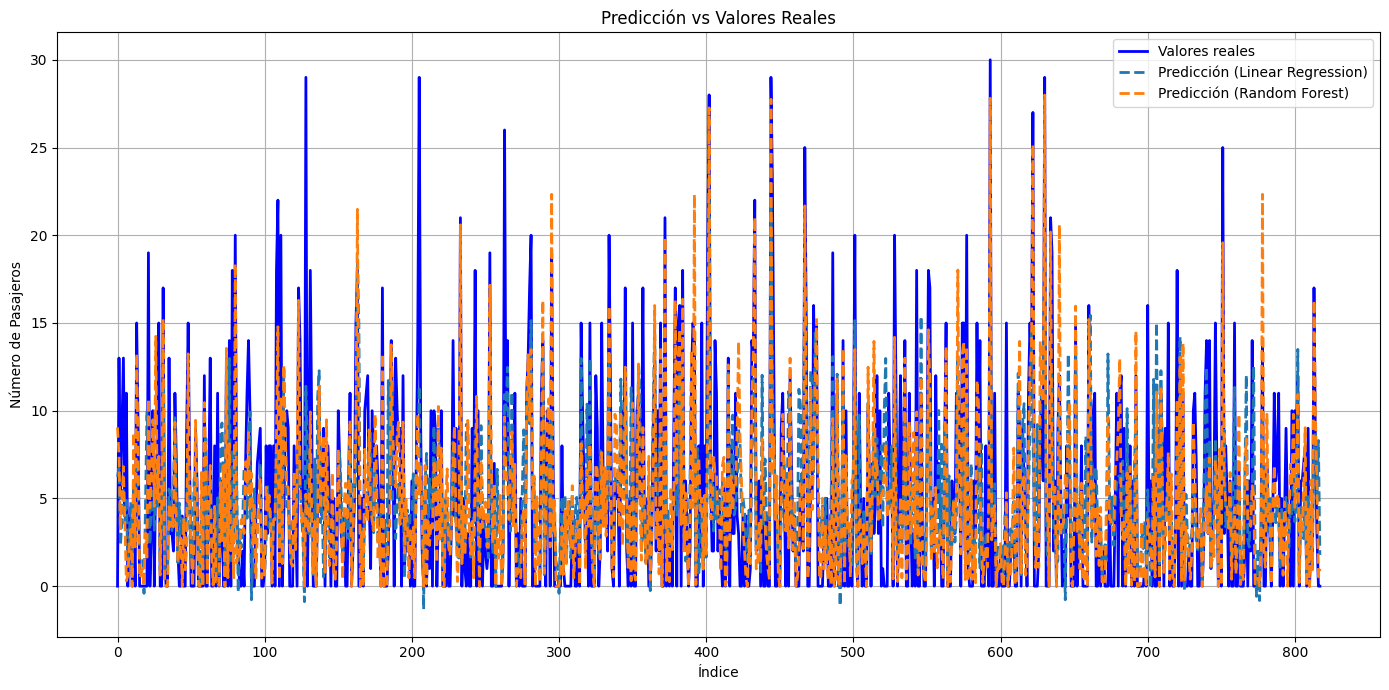

In [11]:
import matplotlib.pyplot as plt

# Gráfico de Predicción vs Valores Reales para cada modelo
plt.figure(figsize=(14, 7))
plt.plot(y_test.values, label='Valores reales', color='blue', linestyle='-', linewidth=2)

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    plt.plot(y_pred, label=f'Predicción ({name})', linestyle='--', linewidth=2)

plt.title('Predicción vs Valores Reales')
plt.xlabel('Índice')
plt.ylabel('Número de Pasajeros')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Modelo XGBoost: MAE = 2.6180154355630574, RMSE = 3.915290944314836, R² = 0.5798726081848145


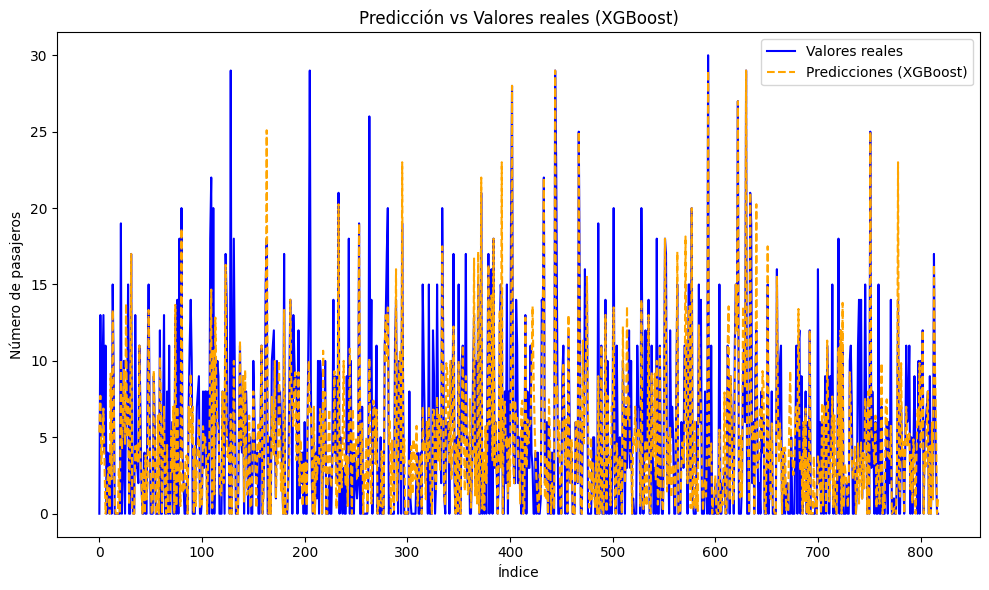

In [12]:
import xgboost as xgb
from sklearn.metrics import r2_score

# Definir el modelo de XGBoost
xgboost_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=300, max_depth=10, random_state=42)

# Entrenar el modelo de XGBoost
xgboost_model.fit(X_train_scaled, y_train)

# Hacer predicciones
y_pred_xgb = xgboost_model.predict(X_test_scaled)

# Calcular métricas de rendimiento
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"Modelo XGBoost: MAE = {mae_xgb}, RMSE = {rmse_xgb}, R² = {r2_xgb}")

# Gráfica de las predicciones vs los valores reales
plt.figure(figsize=(10, 6))
plt.plot(y_test.values, label='Valores reales', color='blue')
plt.plot(y_pred_xgb, label='Predicciones (XGBoost)', color='orange', linestyle='--')
plt.title('Predicción vs Valores reales (XGBoost)')
plt.xlabel('Índice')
plt.ylabel('Número de pasajeros')
plt.legend()
plt.tight_layout()
plt.show()


In [13]:
# Calcular el nivel de confianza (R²) del modelo Random Forest optimizado
r2_best_optimized = models["Random Forest"].score(X_test_scaled, y_test)

# Mostrar el nivel de confianza mejorado
print(f"Nivel de confianza (R²) del modelo optimizado Random Forest: {r2_best_optimized:.4f}")



Nivel de confianza (R²) del modelo optimizado Random Forest: 0.5679


In [14]:
from sklearn.model_selection import GridSearchCV

# Definir el rango de hiperparámetros para optimización
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Crear el modelo Random Forest
rf_model = RandomForestRegressor(random_state=42)

# Configurar GridSearchCV
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=2)

# Ajustar el modelo con los datos de entrenamiento
grid_search.fit(X_train_scaled, y_train)

# Obtener el mejor modelo
best_rf_model = grid_search.best_estimator_

# Evaluar el modelo optimizado
r2_optimized = best_rf_model.score(X_test_scaled, y_test)

# Mostrar el resultado
print(f"Nivel de confianza (R²) del modelo optimizado Random Forest: {r2_optimized:.4f}")


Fitting 3 folds for each of 81 candidates, totalling 243 fits
Nivel de confianza (R²) del modelo optimizado Random Forest: 0.5703


In [15]:
import pandas as pd
import numpy as np

# Crear un DataFrame vacío para el día 17/06/2024 desde las 6:00 hasta las 23:00
date_future = pd.date_range(start='2024-06-17 06:00:00', end='2024-06-17 23:00:00', freq='H')

# Suponer algunos valores estimados para las variables predictoras
# Aquí puedes ajustar estos valores según tendencias anteriores
future_data = pd.DataFrame({
    'Fecha': date_future,
    'Hora': date_future.time,
    'Flujo de personas': np.random.randint(5, 30, size=len(date_future)),  # Puedes basarte en tendencias
    'Flujo de choferes': np.random.randint(3, 15, size=len(date_future)),  # Valores estimados
    'Feriado': [0] * len(date_future),  # Suponemos que no es feriado
    'Eventos inesperados': [0] * len(date_future)  # No hay eventos inesperados
})

# Mostrar las primeras filas del dataset futuro para comprobar los valores
print(future_data.head())


                Fecha      Hora  Flujo de personas  Flujo de choferes  \
0 2024-06-17 06:00:00  06:00:00                  5                  4   
1 2024-06-17 07:00:00  07:00:00                 15                 11   
2 2024-06-17 08:00:00  08:00:00                 24                  7   
3 2024-06-17 09:00:00  09:00:00                 23                 11   
4 2024-06-17 10:00:00  10:00:00                 22                 11   

   Feriado  Eventos inesperados  
0        0                    0  
1        0                    0  
2        0                    0  
3        0                    0  
4        0                    0  


C:\Users\OMEN\AppData\Local\Temp\ipykernel_8812\1168940918.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  date_future = pd.date_range(start='2024-06-17 06:00:00', end='2024-06-17 23:00:00', freq='H')


In [16]:
# Escalar los datos del día futuro usando el mismo scaler que utilizamos en el entrenamiento
future_data_scaled = scaler.transform(future_data[['Flujo de personas', 'Flujo de choferes', 'Feriado', 'Eventos inesperados']])

# Realizar la predicción con el modelo Random Forest entrenado
future_predictions = best_model.predict(future_data_scaled)

# Agregar las predicciones al DataFrame futuro
future_data['Prediccion Numero de pasajeros'] = future_predictions

# Mostrar las predicciones para el 17/06/2024
print(future_data[['Fecha', 'Hora', 'Prediccion Numero de pasajeros']])


NameError: name 'best_model' is not defined

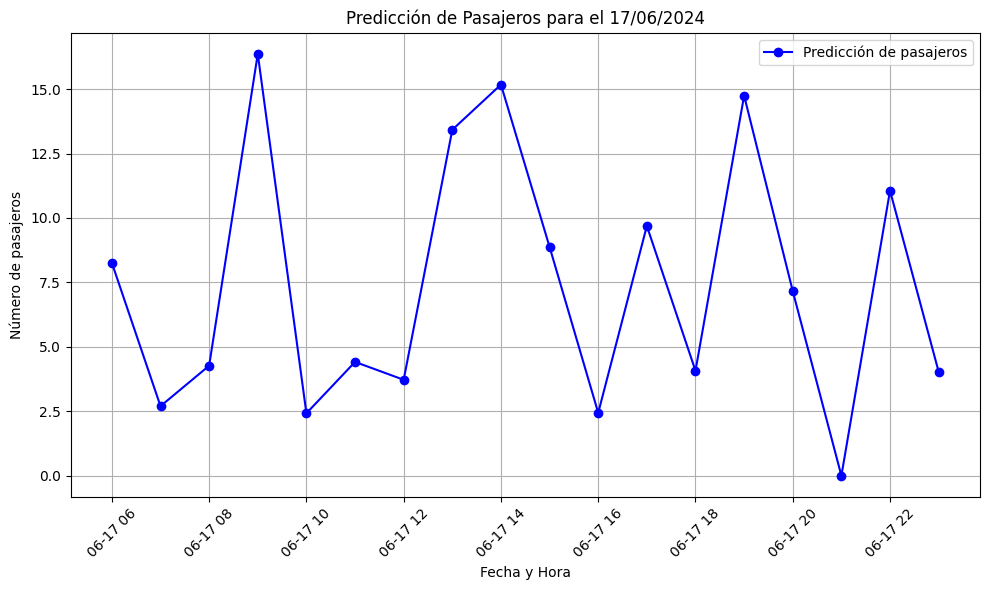

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Supongamos que ya has generado el DataFrame 'future_data' con las predicciones
# Graficar las predicciones usando la columna 'Fecha' (que incluye la hora)
plt.figure(figsize=(10, 6))
plt.plot(future_data['Fecha'], future_data['Prediccion Numero de pasajeros'], marker='o', linestyle='-', color='blue', label='Predicción de pasajeros')
plt.title('Predicción de Pasajeros para el 17/06/2024')
plt.xlabel('Fecha y Hora')
plt.ylabel('Número de pasajeros')
plt.xticks(rotation=45)  # Rotar etiquetas de fecha y hora
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Leer el archivo CSV
data = pd.read_csv("Demanda.csv")

# Eliminar columnas irrelevantes
columns_to_drop = ['Unnamed: 10', 'Parada', 'Eventos inesperados']
data = data.drop(columns=[col for col in columns_to_drop if col in data.columns], axis=1)

# Limpiar nombres de columnas
data.columns = data.columns.str.strip()

# Convertir las columnas 'Fecha' y 'Hora'
data['Fecha'] = pd.to_datetime(data['Fecha'])
data['Hora'] = pd.to_timedelta(data['Hora'].astype(str).str.replace(":", "."), errors='coerce')

# Corregir nombres de días
data['Dia de la semana'] = data['Dia de la semana'].str.strip().replace("Miercoles", "Miércoles")

# Crear variable de días feriados
feriados = ['2024-05-01', '2024-06-21', '2024-07-16']  # Agregar más si es necesario
data['Feriado'] = data['Fecha'].dt.strftime('%Y-%m-%d').isin(feriados).astype(int)

# Crear variables predictoras y objetivo
X = data[['Flujo de personas', 'Flujo de choferes', 'Eventos especiales', 'Dia de la semana', 'Clima']]
y = data['Numero de pasajeros']

# One-Hot Encoding para variables categóricas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['Flujo de personas', 'Flujo de choferes', 'Eventos especiales']),
        ('cat', OneHotEncoder(), ['Dia de la semana', 'Clima'])
    ])

X_processed = preprocessor.fit_transform(X)

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

# Escalar la variable objetivo (opcional para redes neuronales)
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Definir el modelo
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')  # Salida para regresión
])

# Compilar el modelo
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# Entrenar el modelo
history = model.fit(X_train, y_train_scaled, validation_data=(X_test, y_test_scaled),
                    epochs=100, batch_size=32, verbose=1)


Epoch 1/100


c:\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.8076 - mae: 0.6929 - val_loss: 0.5485 - val_mae: 0.5395
Epoch 2/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5583 - mae: 0.5597 - val_loss: 0.5377 - val_mae: 0.5446
Epoch 3/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5648 - mae: 0.5450 - val_loss: 0.5317 - val_mae: 0.5324
Epoch 4/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6040 - mae: 0.5617 - val_loss: 0.5255 - val_mae: 0.5320
Epoch 5/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5590 - mae: 0.5445 - val_loss: 0.5248 - val_mae: 0.5386
Epoch 6/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4916 - mae: 0.5118 - val_loss: 0.5306 - val_mae: 0.5486
Epoch 7/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5242 - mae: 0.5319 - val_loss: 0.5422 - val_mae: 0.5295
Epoch 8/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5443 - mae: 0.5370 - val_loss: 0.5309 - val_mae: 0.5403
Epoch 9/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss:

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


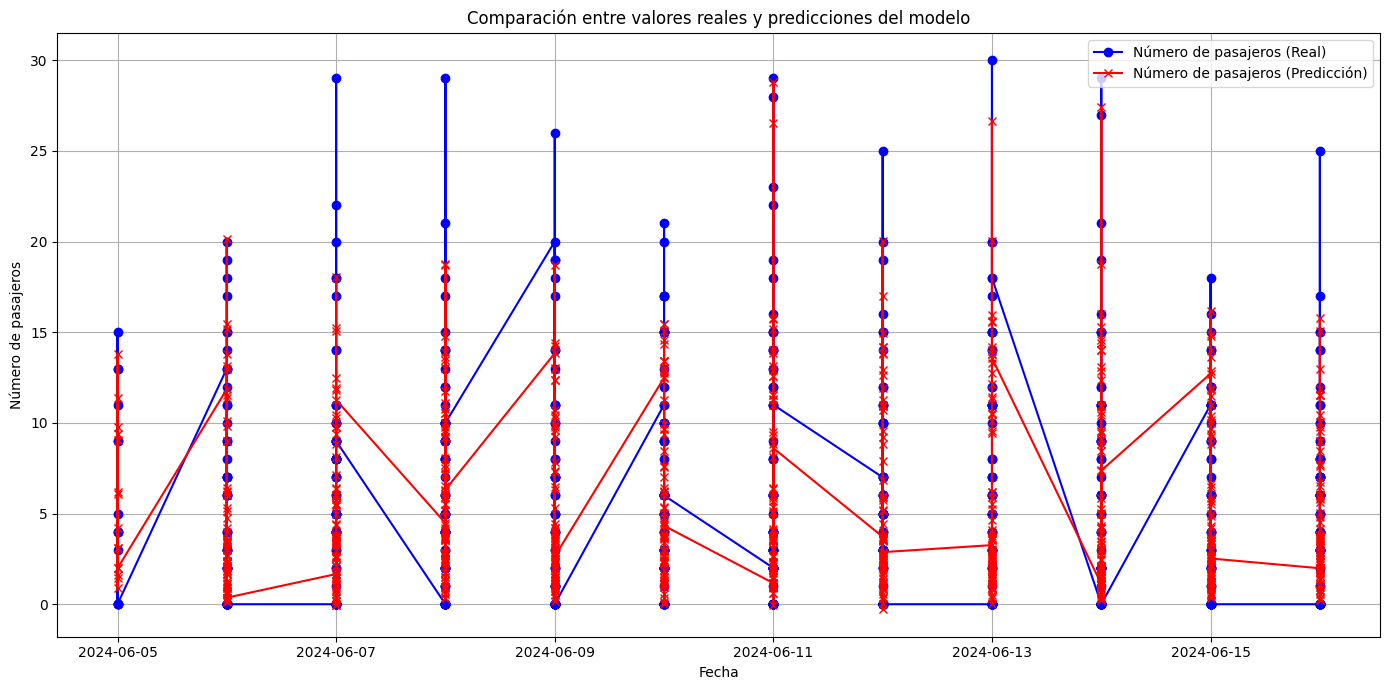

In [ ]:
# Obtener las predicciones
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)  # Desescalar predicciones
y_test_actual = scaler_y.inverse_transform(y_test_scaled)  # Desescalar valores reales

# Crear un DataFrame para los resultados
test_results = pd.DataFrame({
    'Real': y_test_actual.flatten(),
    'Predicción': y_pred.flatten()
})

# Si tienes fechas asociadas en el conjunto de prueba, agrégalas
if 'Fecha' in data.columns:
    test_results['Fecha'] = data.iloc[-len(y_test_actual):]['Fecha'].values

# Ordenar por fecha si está disponible
if 'Fecha' in test_results.columns:
    test_results = test_results.sort_values(by='Fecha')

# Graficar los resultados
plt.figure(figsize=(14, 7))
plt.plot(test_results['Fecha'] if 'Fecha' in test_results.columns else test_results.index,
         test_results['Real'], marker='o', label='Número de pasajeros (Real)', color='blue')
plt.plot(test_results['Fecha'] if 'Fecha' in test_results.columns else test_results.index,
         test_results['Predicción'], marker='x', label='Número de pasajeros (Predicción)', color='red')
plt.title('Comparación entre valores reales y predicciones del modelo')
plt.xlabel('Fecha' if 'Fecha' in test_results.columns else 'Índice')
plt.ylabel('Número de pasajeros')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



Random Forest - Mean Squared Error (MSE): 8.59
Random Forest - Mean Absolute Error (MAE): 1.82
Random Forest - R² Score: 0.76


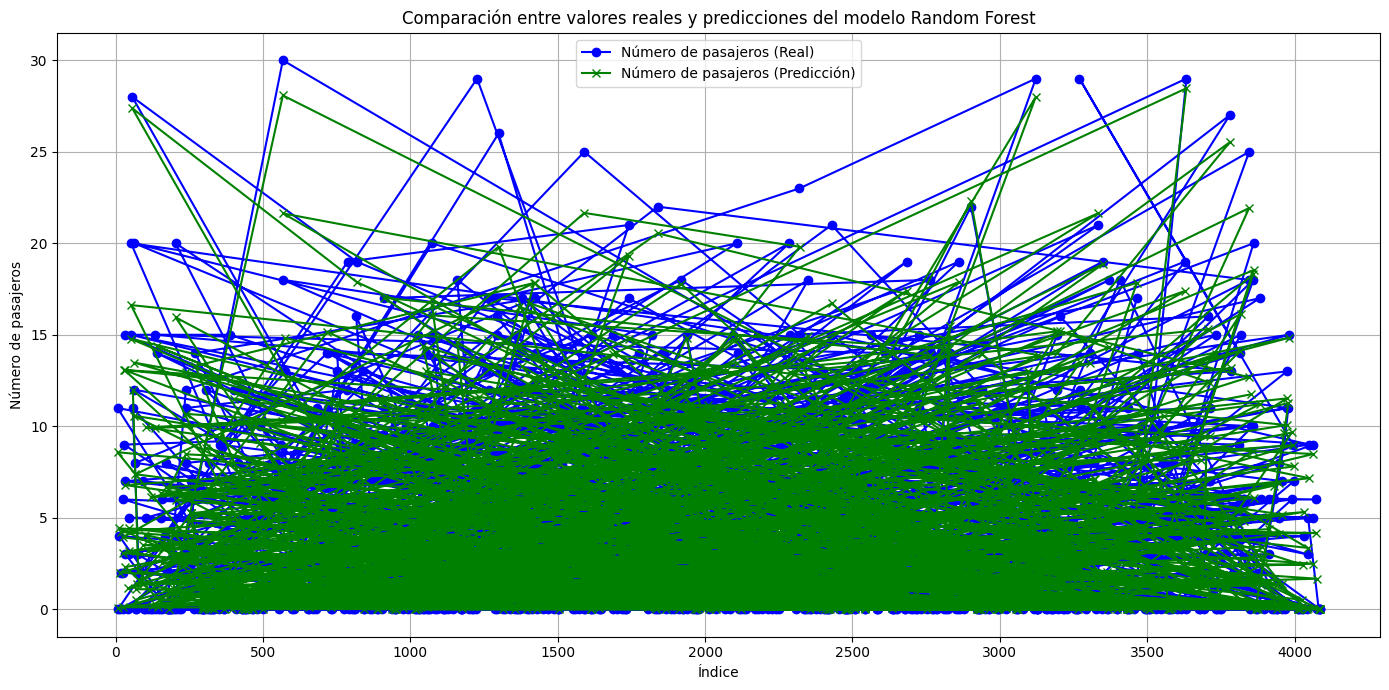

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Crear y entrenar el modelo Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Hacer predicciones
y_rf_pred = rf_model.predict(X_test)

# Evaluar el modelo
mse_rf = mean_squared_error(y_test, y_rf_pred)
mae_rf = mean_absolute_error(y_test, y_rf_pred)
r2_rf = r2_score(y_test, y_rf_pred)

print(f"Random Forest - Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Random Forest - Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"Random Forest - R² Score: {r2_rf:.2f}")

# Crear un DataFrame para los resultados
# Usar el índice de y_test para que coincida con los datos reales
rf_results = pd.DataFrame({
    'Real': y_test,
    'Predicción': y_rf_pred
})

# Graficar los resultados
plt.figure(figsize=(14, 7))
plt.plot(rf_results.index, rf_results['Real'], marker='o', label='Número de pasajeros (Real)', color='blue')
plt.plot(rf_results.index, rf_results['Predicción'], marker='x', label='Número de pasajeros (Predicción)', color='green')
plt.title('Comparación entre valores reales y predicciones del modelo Random Forest')
plt.xlabel('Índice')
plt.ylabel('Número de pasajeros')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Random Forest - Mean Squared Error (MSE): 8.75
Random Forest - Mean Absolute Error (MAE): 1.84
Random Forest - R² Score: 0.76


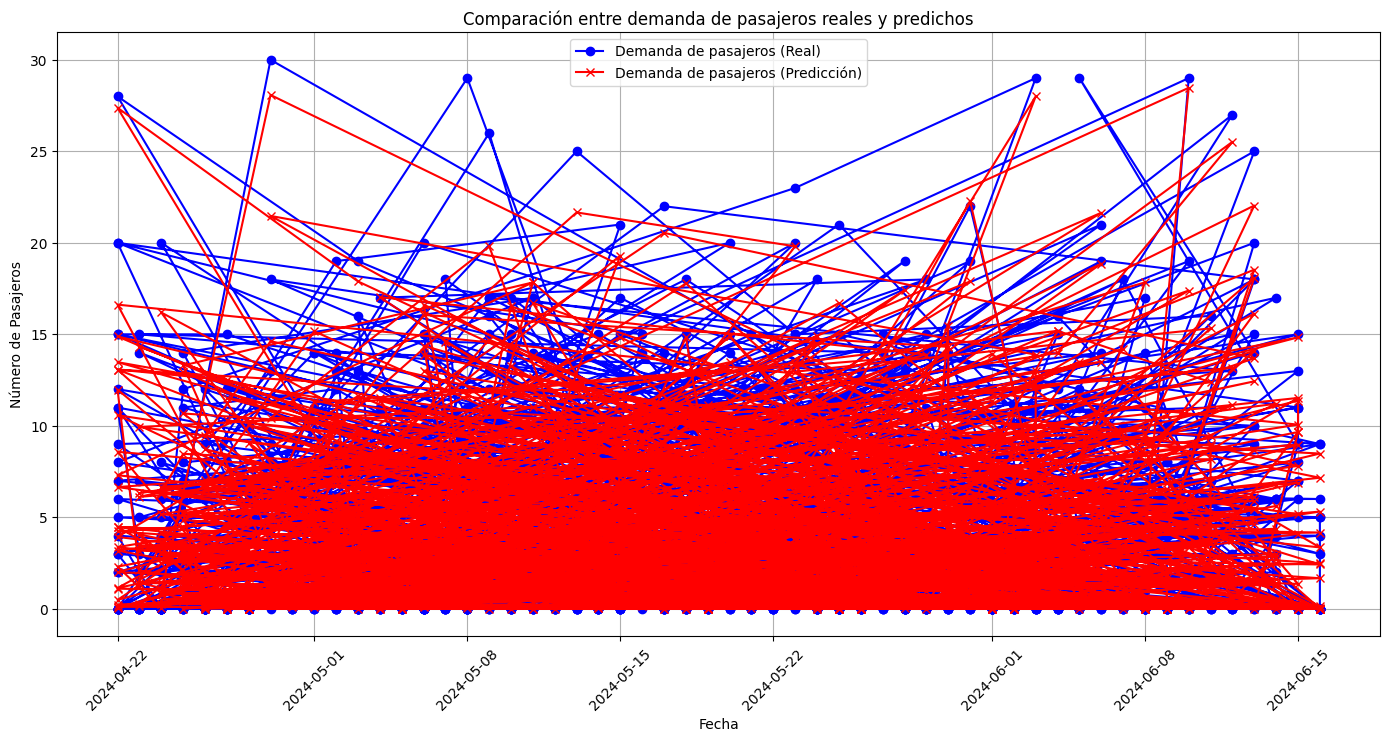

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd

# Variables categóricas y numéricas
categorical_features = ['Dia de la semana', 'Clima']
numerical_features = ['Flujo de personas', 'Flujo de choferes', 'Eventos especiales']

# ColumnTransformer para manejar el preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(), categorical_features)
    ])

# Pipeline con preprocesamiento y modelo
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Dividir los datos
X = data[numerical_features + categorical_features]
y = data['Numero de pasajeros']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar el modelo
rf_pipeline.fit(X_train, y_train)

# Hacer predicciones
y_rf_pred = rf_pipeline.predict(X_test)

# Evaluar el modelo
mse_rf = mean_squared_error(y_test, y_rf_pred)
mae_rf = mean_absolute_error(y_test, y_rf_pred)
r2_rf = r2_score(y_test, y_rf_pred)

print(f"Random Forest - Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Random Forest - Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"Random Forest - R² Score: {r2_rf:.2f}")

# Crear un DataFrame para resultados y fechas
if 'Fecha' in data.columns:
    test_dates = data.iloc[X_test.index]['Fecha']
    rf_results = pd.DataFrame({
        'Fecha': test_dates,
        'Real': y_test.values,
        'Predicción': y_rf_pred
    })
else:
    rf_results = pd.DataFrame({
        'Real': y_test.values,
        'Predicción': y_rf_pred
    })

# Graficar los resultados
plt.figure(figsize=(14, 7))
if 'Fecha' in rf_results.columns:
    plt.plot(rf_results['Fecha'], rf_results['Real'], marker='o', label='Demanda de pasajeros (Real)', color='blue')
    plt.plot(rf_results['Fecha'], rf_results['Predicción'], marker='x', label='Demanda de pasajeros (Predicción)', color='red')
    plt.xlabel('Fecha')
else:
    plt.plot(rf_results.index, rf_results['Real'], marker='o', label='Demanda de pasajeros (Real)', color='blue')
    plt.plot(rf_results.index, rf_results['Predicción'], marker='x', label='Demanda de pasajeros (Predicción)', color='red')
    plt.xlabel('Índice')
    
plt.title('Comparación entre demanda de pasajeros reales y predichos')
plt.ylabel('Número de Pasajeros')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()



Fitting 3 folds for each of 108 candidates, totalling 324 fits
Random Forest Optimizado - Mean Squared Error (MSE): 8.56
Random Forest Optimizado - Mean Absolute Error (MAE): 1.82
Random Forest Optimizado - R² Score: 0.77


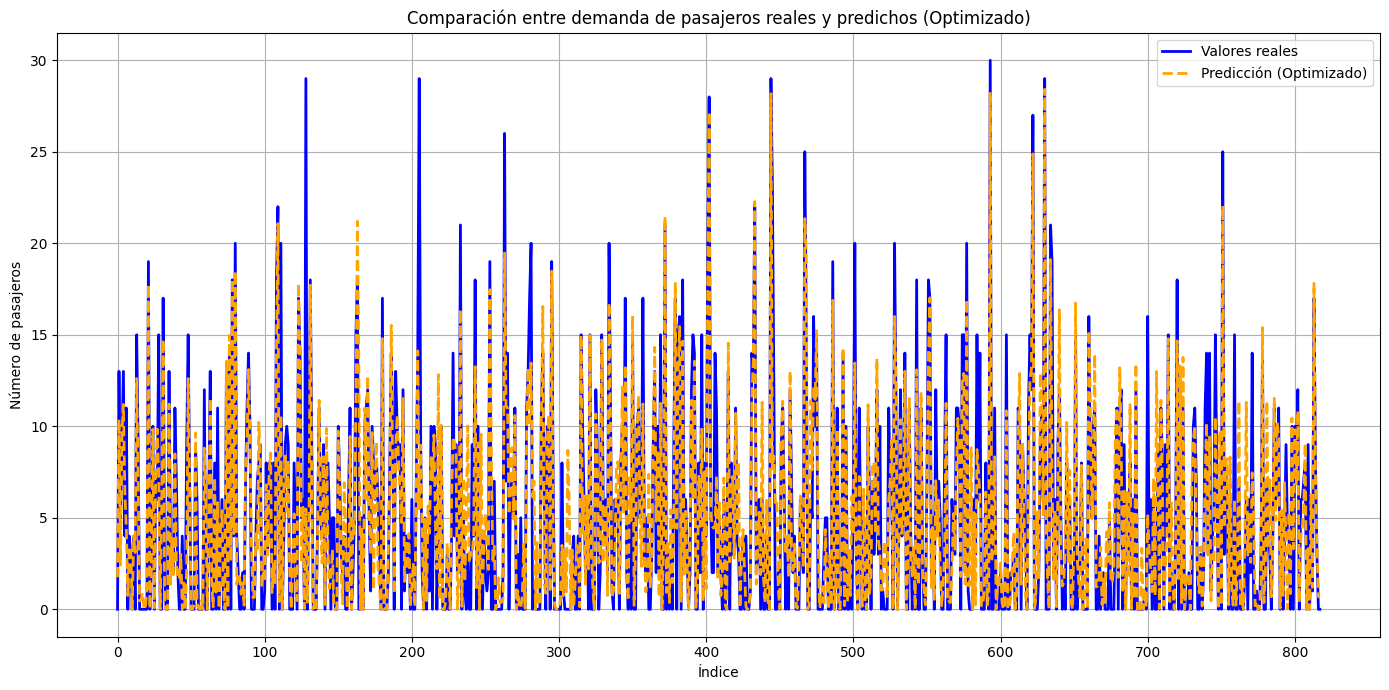

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd

# Definir las características categóricas y numéricas
categorical_features = ['Dia de la semana', 'Clima']
numerical_features = ['Flujo de personas', 'Flujo de choferes', 'Eventos especiales']

# ColumnTransformer para manejar el preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(), categorical_features)
    ])

# Crear el Pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

# Definir el rango de hiperparámetros para optimización
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [10, 20, 30, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

# Configurar GridSearchCV
grid_search = GridSearchCV(estimator=rf_pipeline, param_grid=param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=2)

# Dividir los datos
X = data[numerical_features + categorical_features]
y = data['Numero de pasajeros']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ajustar el modelo con los datos de entrenamiento
grid_search.fit(X_train, y_train)

# Obtener el mejor modelo
best_pipeline = grid_search.best_estimator_

# Hacer predicciones con el mejor modelo
y_pred = best_pipeline.predict(X_test)

# Evaluar el modelo
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Random Forest Optimizado - Mean Squared Error (MSE): {mse:.2f}")
print(f"Random Forest Optimizado - Mean Absolute Error (MAE): {mae:.2f}")
print(f"Random Forest Optimizado - R² Score: {r2:.2f}")

# Graficar los resultados
plt.figure(figsize=(14, 7))
plt.plot(y_test.values, label='Valores reales', color='blue', linestyle='-', linewidth=2)
plt.plot(y_pred, label='Predicción (Optimizado)', linestyle='--', linewidth=2, color='orange')
plt.title('Comparación entre demanda de pasajeros reales y predichos (Optimizado)')
plt.xlabel('Índice')
plt.ylabel('Número de pasajeros')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
